In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
%cd "/content/drive/My Drive/neuroFuzzy"

/content/drive/My Drive/neuroFuzzy


In [20]:
!pip install -r "requirements.txt"

In [ ]:
!python "src/data_loader.py"

Loading fire Excel files...
Fire data shape: (827666, 4)
Fire daily shape: (2550, 4)
Loading weather Excel files...
Weather data shape: (495744, 6)

Master dataset created successfully.
Final shape: (495744, 9)
                      date  district  ...  elevation  dryness_index
123936 2010-01-01 00:00:00    Almora  ...       1650       0.669428
371808 2010-01-01 00:00:00  Dehradun  ...        640       0.384240
247872 2010-01-01 00:00:00  Haridwar  ...        314       0.198846
0      2010-01-01 00:00:00  Nainital  ...       2084       0.600753
123937 2010-01-01 01:00:00    Almora  ...       1650       0.660744

[5 rows x 9 columns]


In [4]:
import pandas as pd

df = pd.read_csv("data/processed/master_dataset.csv")

print("Shape:", df.shape)
print("\nFire Distribution:\n", df['fire_occurred'].value_counts())

Shape: (495744, 9)

Fire Distribution:
 fire_occurred
0.0    493494
1.0      2250
Name: count, dtype: int64


In [4]:
!python "src/baseline_model.py"

Train shape: (420768, 9)
Test shape: (74976, 9)

Train fire rate: 0.004073503688493421
Test fire rate: 0.007148954332052923
              precision    recall  f1-score   support

         0.0       0.99      0.85      0.91     74440
         1.0       0.02      0.37      0.03       536

    accuracy                           0.84     74976
   macro avg       0.51      0.61      0.47     74976
weighted avg       0.99      0.84      0.91     74976



In [15]:
!python "src/balanced.py"

Loading dataset...

Original distribution:
fire_occurred
0.0    493494
1.0      2250
Name: count, dtype: int64

Fire count: 2250
Non-fire count: 493494

Balanced distribution:
fire_occurred
0.0    2250
1.0    2250
Name: count, dtype: int64

Balanced dataset saved to: data/processed/balanced_dataset.csv
Shape: (4500, 9)


In [17]:
df = pd.read_csv("data/processed/balanced_dataset.csv")
som = SOMModel(x=3, y=3, input_len=len(features))
df = som.fit(df, features)

fuzzy_model = FuzzyFireModel(df)
df = fuzzy_model.compute_risk()

df['fuzzy_pred'] = (df['fuzzy_risk'] > 40).astype(int)

SOM training complete.
Zones created: 9


In [18]:
from sklearn.metrics import classification_report

print(classification_report(df['fire_occurred'], df['fuzzy_pred']))

              precision    recall  f1-score   support

         0.0       0.31      0.21      0.25      2250
         1.0       0.40      0.53      0.46      2250

    accuracy                           0.37      4500
   macro avg       0.36      0.37      0.35      4500
weighted avg       0.36      0.37      0.35      4500



In [22]:
from src.som_model import SOMModel
from src.fuzzy_model import FuzzyFireModel

# Load full dataset
df_full = pd.read_csv("data/processed/master_dataset.csv")

features = ['temp','humidity','wind','rain','elevation']

# STEP 1: Assign zones using SOM
som_full = SOMModel(x=3, y=3, input_len=len(features))
df_full = som_full.fit(df_full, features)

# STEP 2: Apply fuzzy
fuzzy_model_full = FuzzyFireModel(df_full)
df_full = fuzzy_model_full.compute_risk()

# STEP 3: Prediction
df_full['fuzzy_pred'] = (df_full['fuzzy_risk'] > 40).astype(int)

# STEP 4: Evaluation
from sklearn.metrics import classification_report
print(classification_report(df_full['fire_occurred'], df_full['fuzzy_pred']))

SOM training complete.
Zones created: 8
              precision    recall  f1-score   support

         0.0       0.99      0.29      0.45    493494
         1.0       0.00      0.46      0.01      2250

    accuracy                           0.29    495744
   macro avg       0.50      0.37      0.23    495744
weighted avg       0.99      0.29      0.45    495744



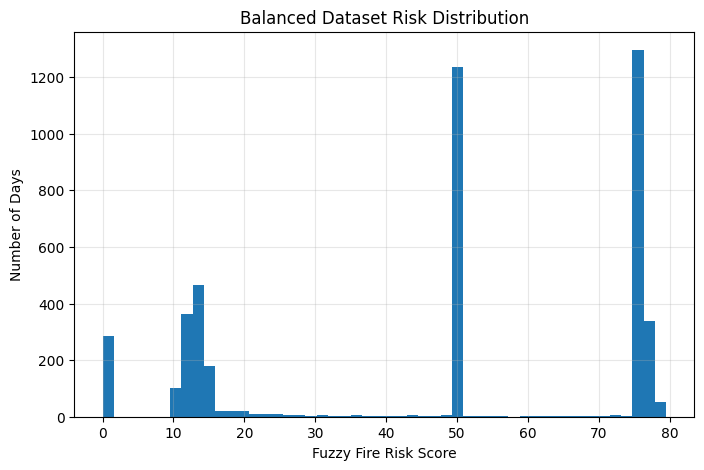

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['fuzzy_risk'], bins=50)

plt.xlabel("Fuzzy Fire Risk Score")
plt.ylabel("Number of Days")
plt.title("Balanced Dataset Risk Distribution")

plt.grid(alpha=0.3)
plt.show()

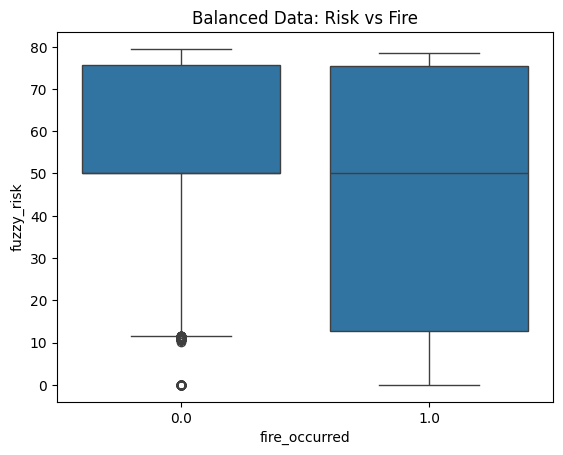

In [27]:
import seaborn as sns

sns.boxplot(x='fire_occurred', y='fuzzy_risk', data=df)

plt.title("Balanced Data: Risk vs Fire")
plt.show()

In [29]:
for t in [30, 40, 50, 60, 70]:
    pred = (df['fuzzy_risk'] > t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(df['fire_occurred'], pred))


Threshold: 30
              precision    recall  f1-score   support

         0.0       0.31      0.20      0.24      2250
         1.0       0.40      0.54      0.46      2250

    accuracy                           0.37      4500
   macro avg       0.35      0.37      0.35      4500
weighted avg       0.35      0.37      0.35      4500


Threshold: 40
              precision    recall  f1-score   support

         0.0       0.31      0.21      0.25      2250
         1.0       0.40      0.53      0.46      2250

    accuracy                           0.37      4500
   macro avg       0.36      0.37      0.35      4500
weighted avg       0.36      0.37      0.35      4500


Threshold: 50
              precision    recall  f1-score   support

         0.0       0.44      0.42      0.43      2250
         1.0       0.44      0.46      0.45      2250

    accuracy                           0.44      4500
   macro avg       0.44      0.44      0.44      4500
weighted avg       0.44      